In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')

# Sampling

In statistics, we are often interested in certain population parameters. However, to obtain these population statistics, we would need data from the entire population, which is frequently not feasible. This is where sampling comes into play. If we assume that the sample we have shares similar characteristics with the population, then the sample statistic can represent the population statistic.



In [2]:
np.random.seed(42)
population = np.random.exponential(scale=5, size=1000)
sample = np.random.choice(population, size=30)

print("Population Mean:", np.mean(population))
print("Sample Mean:", np.mean(sample))

second_sample = np.random.choice(population, size=30)
print("Second Sample Mean:", np.mean(second_sample))

Population Mean: 4.862529739826122
Sample Mean: 5.318017887417192
Second Sample Mean: 4.884294343639795


The two samples gave different results. But which one is correct? We don't know. However, if we repeat this sampling process many times, something interesting happens:

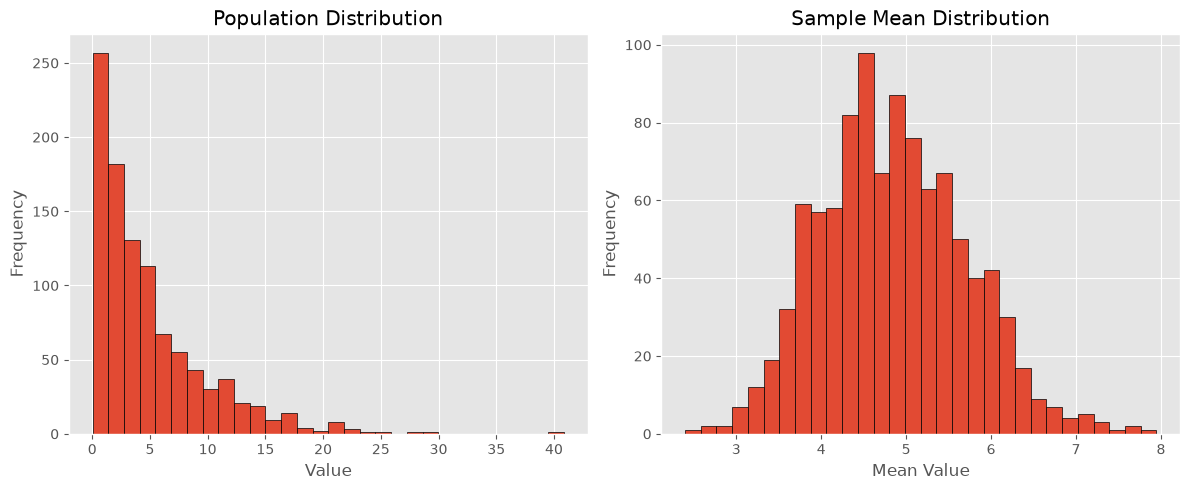

In [3]:
sample_means = []
for i in range(1000):
    sample = np.random.choice(population, size=30)
    sample_means.append(np.mean(sample))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(population, bins=30, edgecolor='black')
ax[0].set_title('Population Distribution')
ax[0].set_xlabel('Value')
ax[0].set_ylabel('Frequency')

ax[1].hist(sample_means, bins=30, edgecolor='black')
ax[1].set_title('Sample Mean Distribution')
ax[1].set_xlabel('Mean Value')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Independent of the population's characteristics, if we sample repeatedly, the distribution of sample statistics approaches a normal distribution. This is called the Central Limit Theorem (CLT).

Since the distribution of sample statistics is normal, we can make inferences using the properties of the normal distribution. For example, instead of reporting the sample mean itself, we can acknowledge the error that comes with sampling and report a confidence interval.

In [4]:
confidence_interval = np.percentile(sample_means, 2.5), np.percentile(sample_means, 97.5)
print("Population Mean 95% Confidence Interval:", confidence_interval)

Population Mean 95% Confidence Interval: (np.float64(3.3454317831314753), np.float64(6.614663104789146))


The standard deviation of the sample statistics is called the "standard error". It is formulated as

$SE = \frac{\sigma}{\sqrt{n}}$

Intuitively, as the variability of the population increases, the deviation of the sample statistics becomes larger. And as the sample size increases, the expected variability decreases.

In [5]:
standard_error = np.std(sample_means)
print("Sample Mean Standard Error (empirical):", standard_error)

theoretical_se = np.std(population) / np.sqrt(30)
print("Sample Mean Standard Error (theoretical):", theoretical_se)

Sample Mean Standard Error (empirical): 0.8598959713481776
Sample Mean Standard Error (theoretical): 0.8873320043825554


There are a variety of sampling methodologies. Each of them serves a different purpose.



## Sampling Methods

### Random Sampling

Random sampling refers to gathering data points from the population at random. In most cases, it is the best way to ensure that the sample appropriately represents the population.

In [6]:
population = np.random.randint(0,100,1000)
sample = np.random.choice(population,size = 100)
sample

array([42,  3, 47, 69, 90, 51, 40, 44, 29, 43, 62, 13, 78, 64, 44, 87,  9,
       94, 72, 52, 73,  4, 23, 23, 22, 70, 47, 34, 67, 10, 69, 74, 62, 79,
       92, 73, 96, 94, 57, 70, 69,  9, 17, 73, 15, 63, 28,  3,  1,  2, 25,
       95,  2, 19, 45, 48, 79,  3, 27,  9, 84, 49, 12, 23, 82, 88, 94, 47,
       15, 14, 55, 47, 74, 34, 19, 96, 59, 58, 40, 72, 97, 62, 73, 90, 95,
        9, 25, 72, 40, 54, 13, 45, 66, 24, 99, 46, 57, 13, 51,  8],
      dtype=int32)

### Stratified Sampling

Stratified sampling is extremely useful when the population is imbalanced. In such cases, if we sample randomly, there is a high chance that minority groups will be underrepresented. Therefore, we divide the population into subcategories and randomly sample from each of them.

In [7]:
np.random.seed(42)
population = np.array(100*[1] + 900*[0])
np.random.shuffle(population)

ones = population[np.where(population == 1)]
zeros = population[np.where(population == 0)]
proportion = len(ones) / len(zeros)
sample_size = 100

sample1 = np.random.choice(ones,size = int(proportion*sample_size))
sample0 = np.random.choice(zeros,size = int((1-proportion)*sample_size))
sample = np.concatenate((sample0,sample1))
sample

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

### Cluster Sampling

Cluster sampling is useful when the population is naturally divided into groups (clusters), such as cities or schools. Instead of sampling from all groups, we randomly select a few clusters and include all members within the selected clusters. (If we were to sample within the selected clusters as well, instead of including all members, this would be called two stage cluster sampling.)

In [8]:
np.random.seed(42)

data = {
    'Adana': np.random.randint(0,100,100),
    'İstanbul': np.random.randint(0,100,100),
    'Ankara': np.random.randint(0,100,100),
    'Antakya': np.random.randint(0,100,100),
    'Malatya': np.random.randint(0,100,100),
    'Yozgat': np.random.randint(0,100,100),
}

clusters = 3

random_clusters = np.random.choice(list(data.keys()), size = clusters, replace = False)
sample = np.array([data[random_cluster] for random_cluster in random_clusters]).ravel()
sample

array([25, 88, 59, 40, 28, 14, 44, 64, 88, 70,  8, 87,  0,  7, 87, 62, 10,
       80,  7, 34, 34, 32,  4, 40, 27,  6, 72, 71, 11, 33, 32, 47, 22, 61,
       87, 36, 98, 43, 85, 90, 34, 64, 98, 46, 77,  2,  0,  4, 89, 13, 26,
        8, 78, 14, 89, 41, 76, 50, 62, 95, 51, 95,  3, 93, 22, 14, 42, 28,
       35, 12, 31, 70, 58, 85, 27, 65, 41, 44, 61, 56,  5, 27, 27, 43, 83,
       29, 61, 74, 91, 88, 61, 96,  0, 26, 61, 76,  2, 69, 71, 26,  8, 61,
       36, 96, 50, 43, 23, 78, 58, 31, 95, 87, 51, 61, 57, 51, 11, 38,  1,
        2, 55, 80, 58,  1,  1, 91, 53, 86, 95, 96,  0, 18,  1, 52, 43, 89,
       31, 69, 31, 67, 54, 74, 55, 16, 37, 23, 68, 97, 69, 85, 10, 15, 96,
       72, 58, 69, 79, 92,  2, 19, 58, 35, 18, 89, 66, 18, 19, 95, 70, 51,
       32, 39, 38, 81,  0, 10, 91, 56, 88, 49, 22, 30, 93, 41, 98,  6, 15,
       89, 59,  1,  0, 47, 11, 68, 36, 31,  8, 98, 18, 47, 51, 92, 14, 71,
       60, 20, 82, 86, 74, 74, 87, 99, 23,  2, 21, 52,  1, 87, 29, 37,  1,
       63, 59, 20, 32, 75